# Exploratory Data Analysis

## Import Packages:

In [54]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
md_f = open("EDA.md", "w", encoding="UTF-8")

## Load Data:

In [55]:
# Load data and sample
file_path = os.path.abspath("../data/telco_customer_churn.csv")
df = pd.read_csv(file_path, index_col="customerID")
temp_f = df.sample(5)
md_f.write(f"# **Telcom Customer Churn Exploratory Data Analysis**\n")
md_f.write(f"---\n## **Sample Data:**\n")
md_f.write(f"{temp_f.to_markdown()}\n\n")
temp_f

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
3274-NSDWE,Female,0,No,No,68,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.60,1441.65,No
1571-SAVHK,Male,0,No,No,12,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,99.95,1132.75,Yes
4727-MCYZG,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,55.55,55.55,No
9819-FBNSV,Male,1,Yes,No,37,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),72.25,2575.45,No
0743-HRVFF,Female,0,Yes,Yes,51,No,No phone service,DSL,No,No,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,56.15,2898.95,No


## Data Overview:
Complete data overview.
- Dataset Shape
- Convert `TotalCharges` column into float Dtype and NaN blank string
- Only `TotalCharges` have NaN values in this dataset
- Fill NaN with **median** in `TotalCharges`

## Shape:
- Rows = 7043
- Columns = 20


In [56]:
# Shape of data
n_rows, n_cols = df.shape

md_f.write("---\n---\n## **Data Overview:**\n")
md_f.write(f"```\nRows: {n_rows}\n")
md_f.write(f"Columns: {n_cols}\n```\n\n")

print("Rows:", n_rows)
print("Columns:", n_cols)

Rows: 7043
Columns: 20


In [57]:
# Data Overview Function

def overview(df: pd.DataFrame):
    df_new = df.replace(r'^\s*$', np.nan, regex=True)
    # Convert float dtype and set NaN in blank string
    for col in df_new.columns:
        converted = pd.to_numeric(df_new[col], errors='coerce')
        numeric_ratio = converted.notna().mean()
        if numeric_ratio > 0.9:
            df_new[col] = converted
    
    df_describe = df_new.describe(include="all").round(2).T

    # Each column total & percentage of NaN, Dtypes and Uniques
    describe = pd.DataFrame({
        'total_nan': df_new.isnull().sum(),
        'nan%': (df_new.isnull().mean().round(4) * 100).astype(str) + '%',
        'dtypes': df_new.dtypes,
        'uniques': df_new.nunique(),
        'mean': df_describe['mean'],
        'median': df_new.median(numeric_only=True),
        'mode': df_new.mode().T[0],
        'std': df_describe['std'],
        'min': df_describe['min'],
        '25%': df_describe['25%'],
        '50%': df_describe['50%'],
        '75%': df_describe['75%'],
        'max': df_describe['max']
        }).fillna("-")
        
    dup_rows = df_new.duplicated().sum()
    dup_cols = df_new.T.duplicated().sum()


    print(f"Duplicated Columns: {dup_cols} ({dup_cols/n_cols * 100:.1f}%)")
    print(f"Duplicated Rows: {dup_rows} ({dup_rows/n_rows * 100:.1f}%)")
    print(f"Total NaN Values: {df_new.isnull().sum().sum()}")
    print(f"Total NaN Rows: {df.shape[0] - df_new.dropna().shape[0]}")
    print(f"Total NaN Rows Percentage: {(df.shape[0] - df_new.dropna().shape[0])/df.shape[0] * 100:.2f}%")
    
    # Create report
    info = f"```\nDuplicated Columns: {dup_cols} ({dup_cols/n_cols * 100:.1f}%)\n"
    info += f"Duplicated Rows: {dup_rows} ({dup_rows/n_rows * 100:.1f}%)\n```\n"
    info += f"```\nTotal NaN Values: {df_new.isnull().sum().sum()}\n"
    info += f"Total NaN Rows: {df.shape[0] - df_new.dropna().shape[0]}\n"
    info += f"Total NaN Rows Percentage: {(df.shape[0] - df_new.dropna().shape[0])/df.shape[0] * 100:.2f}%\n```\n"
    info += f"{describe.to_markdown()}\n\n"

    df_new['TotalCharges'] = df_new['TotalCharges'].fillna(df_new['TotalCharges'].median())
    return info, df_new, describe

In [58]:
# Get Data Overview
md_info, df, describe= overview(df)
md_f.write(f"{md_info}\n\n")
describe

Duplicated Columns: 0 (0.0%)
Duplicated Rows: 22 (0.3%)
Total NaN Values: 11
Total NaN Rows: 11
Total NaN Rows Percentage: 0.16%


,total_nan,nan%,dtypes,uniques,mean,median,mode,std,min,25%,50%,75%,max
Churn,0,0.0%,str,2,-,-,No,-,-,-,-,-,-
Contract,0,0.0%,str,3,-,-,Month-to-month,-,-,-,-,-,-
Dependents,0,0.0%,str,2,-,-,No,-,-,-,-,-,-
DeviceProtection,0,0.0%,str,3,-,-,No,-,-,-,-,-,-
InternetService,0,0.0%,str,3,-,-,Fiber optic,-,-,-,-,-,-
MonthlyCharges,0,0.0%,float64,1585,64.76,70.35,20.05,30.09,18.25,35.5,70.35,89.85,118.75
MultipleLines,0,0.0%,str,3,-,-,No,-,-,-,-,-,-
OnlineBackup,0,0.0%,str,3,-,-,No,-,-,-,-,-,-
OnlineSecurity,0,0.0%,str,3,-,-,No,-,-,-,-,-,-
PaperlessBilling,0,0.0%,str,2,-,-,Yes,-,-,-,-,-,-


## Data Category

| Data Category | Columns |
|---|---|
| **Numeric Data** | `tenure`, `TotalCharges`, `MonthlyCharges` |
| **Binary Numeric Data** | `SeniorCitizen` |
| **Binary Categorical Data** | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn` |
| **Multiclass Ordinal Data** | `Contract` |
| **Multiclass Nominal Data** | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaymentMethod` |

In [59]:
# Data type and uniques
dtype_unique = pd.concat((df.dtypes, df.nunique()), axis="columns")
dtype_unique.columns = ['Dtypes', 'Uniques']
dtype_unique.sort_values('Uniques')

,Dtypes,Uniques
gender,str,2
SeniorCitizen,int64,2
Partner,str,2
Dependents,str,2
PhoneService,str,2
PaperlessBilling,str,2
Churn,str,2
InternetService,str,3
TechSupport,str,3
OnlineSecurity,str,3


In [60]:
# Binary and Multiclass data type

print("Uniques values of binary data columns:")
for col in dtype_unique["Uniques"][dtype_unique["Uniques"] == 2].index:
    print("○ ", col, ": ",sorted(df[col].unique().tolist()), sep="")

print("\nUniques values of Multiclass data columns:")
for col in dtype_unique["Uniques"][(dtype_unique["Uniques"] == 3) | (dtype_unique["Uniques"] == 4)].index:
    print("○ ", col, ": ",sorted(df[col].unique().tolist()), sep="")

Uniques values of binary data columns:
○ gender: ['Female', 'Male']
○ SeniorCitizen: [0, 1]
○ Partner: ['No', 'Yes']
○ Dependents: ['No', 'Yes']
○ PhoneService: ['No', 'Yes']
○ PaperlessBilling: ['No', 'Yes']
○ Churn: ['No', 'Yes']

Uniques values of Multiclass data columns:
○ MultipleLines: ['No', 'No phone service', 'Yes']
○ InternetService: ['DSL', 'Fiber optic', 'No']
○ OnlineSecurity: ['No', 'No internet service', 'Yes']
○ OnlineBackup: ['No', 'No internet service', 'Yes']
○ DeviceProtection: ['No', 'No internet service', 'Yes']
○ TechSupport: ['No', 'No internet service', 'Yes']
○ StreamingTV: ['No', 'No internet service', 'Yes']
○ StreamingMovies: ['No', 'No internet service', 'Yes']
○ Contract: ['Month-to-month', 'One year', 'Two year']
○ PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


In [61]:
ordinal={
        'Contract': ['Month-to-month', 'One year', 'Two year'],
        'gender': ['Female', 'Male'],
        'Partner': ['No', 'Yes'],
        'Dependents': ['No', 'Yes'],
        'PhoneService': ['No', 'Yes'],
        'PaperlessBilling': ['No', 'Yes']
    }
list(ordinal.keys())
list(ordinal.values())

[['Month-to-month', 'One year', 'Two year'],
 ['Female', 'Male'],
 ['No', 'Yes'],
 ['No', 'Yes'],
 ['No', 'Yes'],
 ['No', 'Yes']]

In [62]:

# Write Category of data in Markdown file manually
md_f.write("""---\n---\n## **Data Categories:**
| Data Category | Columns |
|---|---|
| **Numeric Data** | `tenure`, `TotalCharges`, `MonthlyCharges` |
| **Binary Numeric Data** | `SeniorCitizen` |
| **Binary Categorical Data** | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn` |
| **Multiclass Ordinal Data** | `Contract` |
| **Multiclass Nominal Data** | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `PaymentMethod` |
""")


529

## Data Distribution:

### Imbalance
The dataset is moderately imbalanced:

- Non-churn customers: 73.5%
- Churn customers: 26.5%

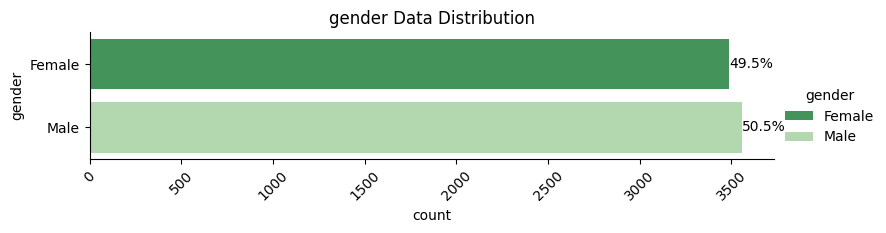

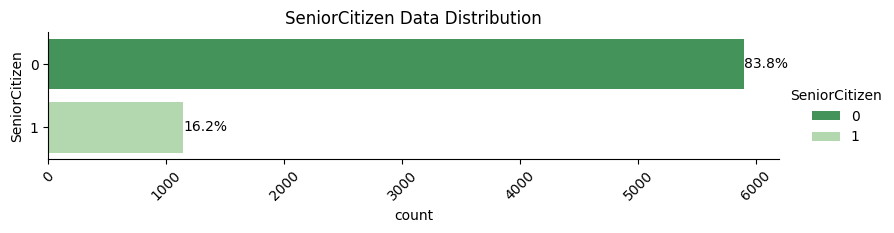

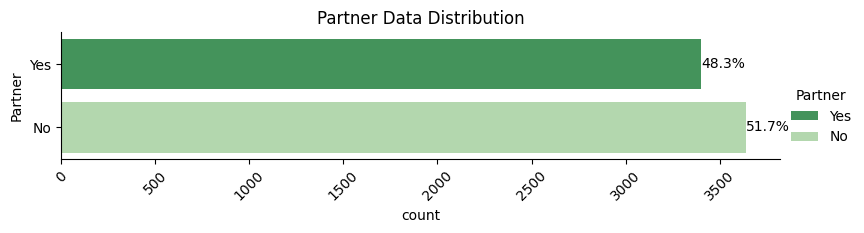

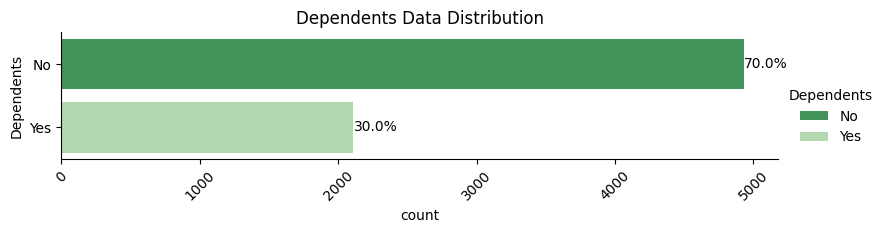

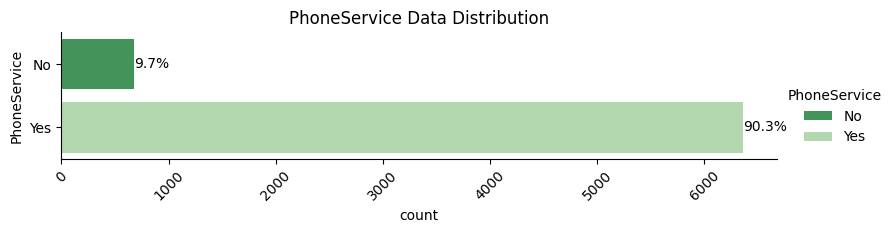

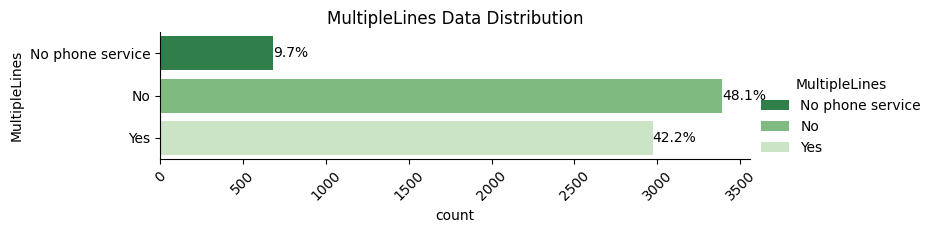

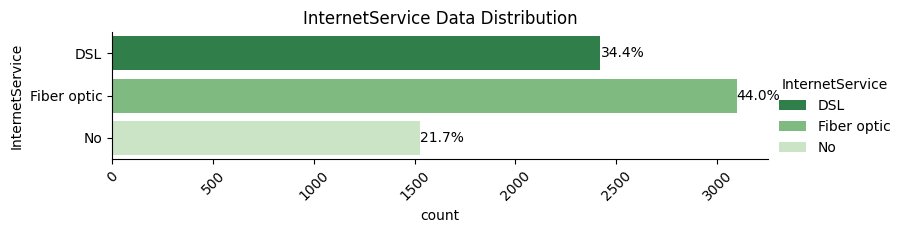

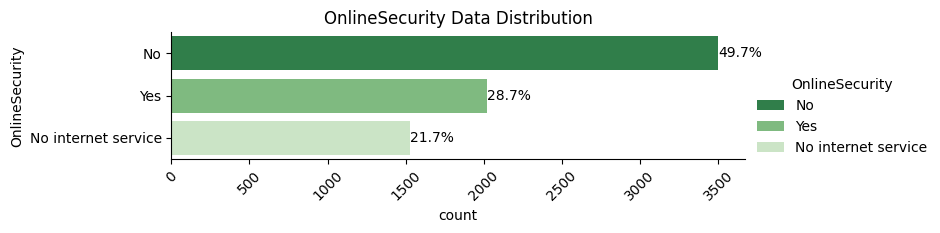

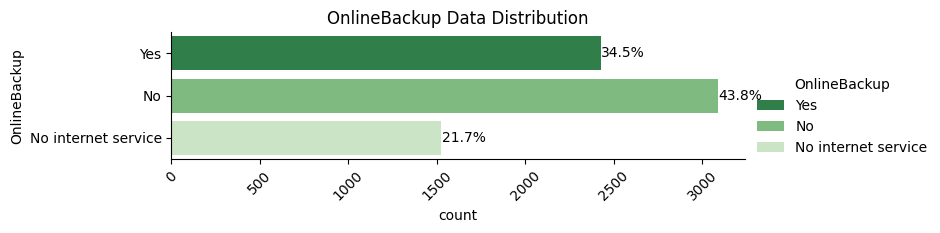

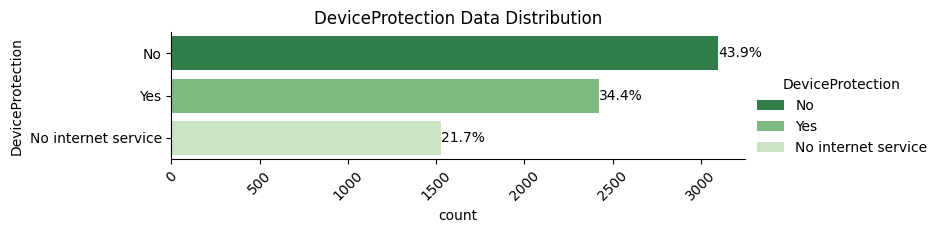

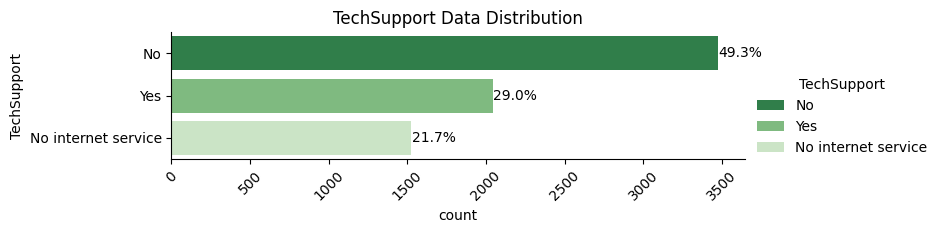

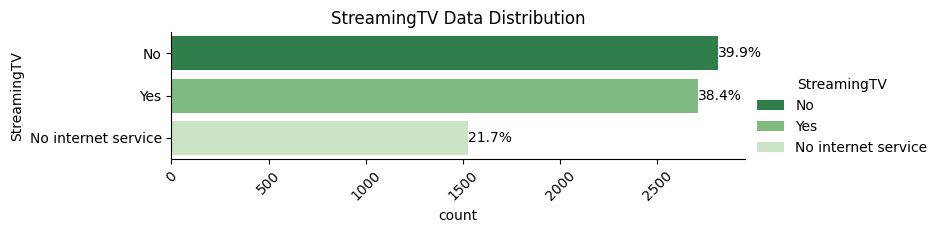

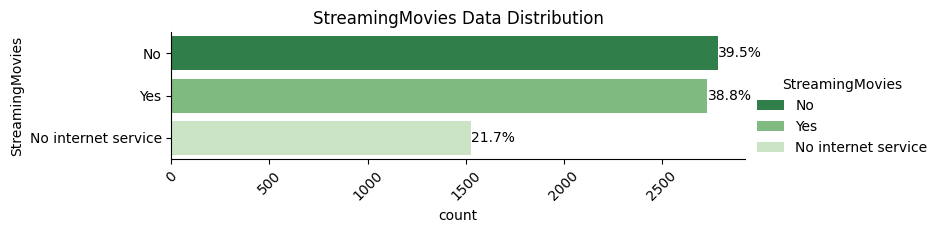

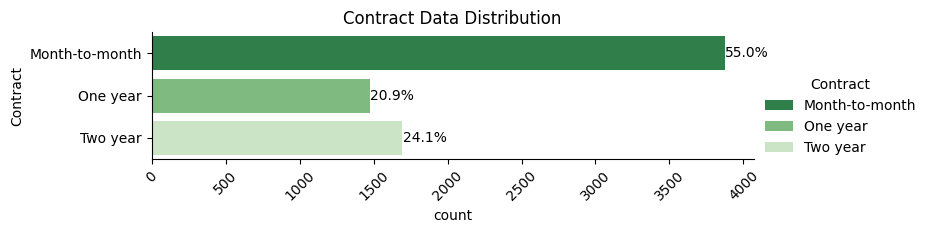

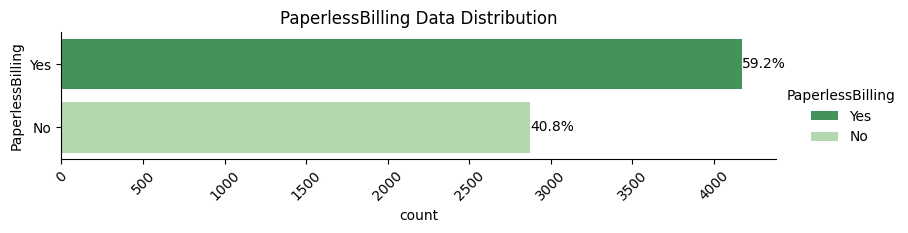

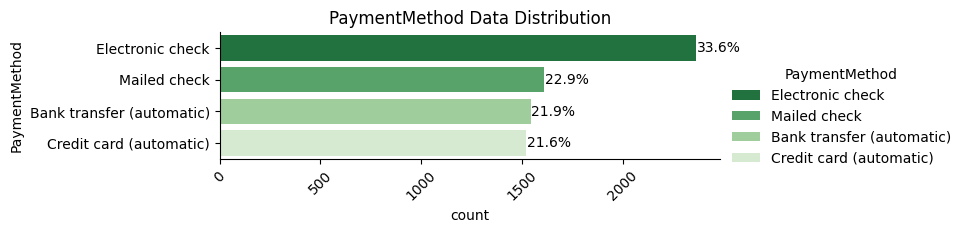

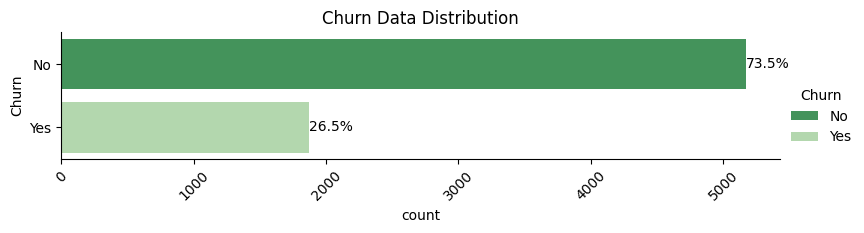

In [63]:
# Countplot for Data Distribution

def countplot(df: pd.DataFrame, col: str):

    co = sns.catplot(
        kind="count",
        data=df,
        y=col,
        hue=col,
        palette='Greens_r',
        legend=True,
        height=2,
        aspect=4
    )

    ax = co.ax

    for p in ax.patches:

        if p.get_width() > 0:   # important fix

            ax.annotate(
                f'{100 * p.get_width()/len(df):.1f}%',

                (
                    p.get_width() + 1,
                    p.get_y() + p.get_height()/2
                ),

                va='center'
            )
    plt.xticks(rotation=45)
    plt.title(f"{col} Data Distribution")

    plt.savefig(f"images/{col}_countplot.svg", bbox_inches='tight')
    plt.show()

md_f.write("---\n---\n## **Data Distribution:**\n\n")
for col in dtype_unique["Uniques"][dtype_unique["Uniques"] <= 10].index:
    countplot(df, col)

    md_f.write(f"### {col} Data Distribution:\n\n")
    md_f.write(f"![{col} Distribution Graph](images/{col}_countplot.svg)\n\n")

In [64]:
# Churn Data Imbalance

imb_churn = pd.DataFrame(df["Churn"].value_counts())
imb_churn["pct_count"] = df['Churn'].value_counts(normalize=True).round(3) * 100
imb_churn["pct_count"] = imb_churn["pct_count"].astype(str) + "%"
md_f.write(f"---\n---\n## **Churn Data Imbalance:**\n")
md_f.write(f"- Non-churn customers: {imb_churn["pct_count"].loc["No"]}%\n\n")
md_f.write(f"- Churn customers: {imb_churn["pct_count"].loc["Yes"]}%\n\n")
md_f.write(f"{imb_churn.to_markdown()}\n\n")

imb_churn

,count,pct_count
Churn,,
No,5174,73.5%
Yes,1869,26.5%


In [65]:
# Outliers

def multi_threshold_outliers(df, thresholds=[1, 1.5, 2, 2.5, 3, 4]):
    results = []

    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        row = {"column": col}

        for t in thresholds:
            lower = Q1 - t * IQR
            upper = Q3 + t * IQR

            outliers_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

            row[f"t_{t}"] = outliers_count

        results.append(row)

    return pd.DataFrame(results)

outlier_table = multi_threshold_outliers(df)

md_f.write(f"---\n---\n## **Outlier:**\nOutliers on different thresholds.\n\n")
md_f.write(f"{outlier_table.to_markdown()}\n\n")


outlier_table

,column,t_1,t_1.5,t_2,t_2.5,t_3,t_4
0,tenure,0,0,0,0,0,0
1,MonthlyCharges,0,0,0,0,0,0
2,TotalCharges,277,0,0,0,0,0


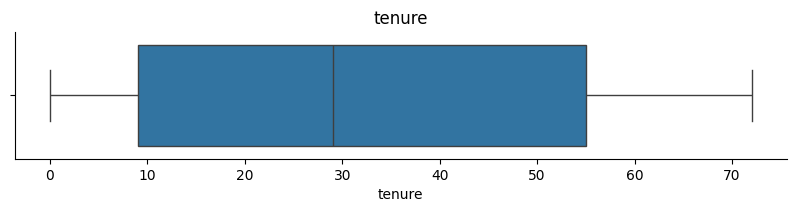

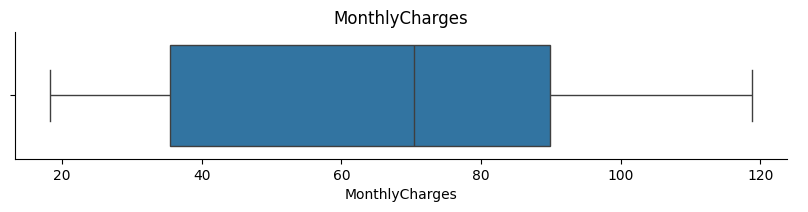

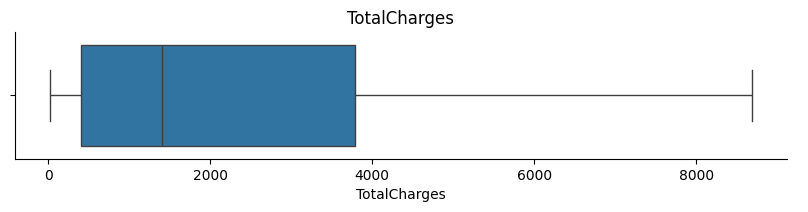

In [66]:
# Outliers Boxplots

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    sns.catplot(
        kind="box",
        data=df,
        x=col,
        orient="h",
        height=2,
        aspect=4
    ).savefig(fig_path:=f"images/outliers_boxplot_{col}.svg", bbox_inches='tight')
    plt.title(col)
    plt.show()
    md_f.write(f"![BoxPlot]({fig_path})\n\n")


## Relational Analysis:

## Bivariate Analysis

### 1. Contract vs Churn:
- Month-to-month → high churn
- 2-year contract → low churn

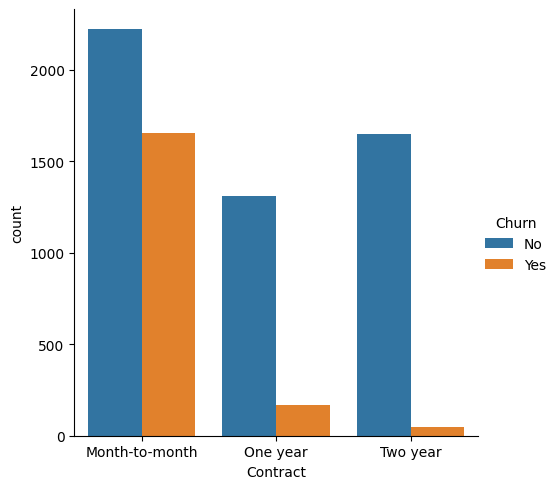

In [67]:
sns.catplot(kind="count", x='Contract', hue='Churn', data=df).savefig("images/contract_vs_churn.svg", bbox_inches="tight")

In [68]:
# Analyze contract with churn rate
print(f"Month-to-month, high churnn")
print(f"2-year contract, low churn")

md_f.write(f"---\n---\n## **Bivariate Analysis:**\n")
md_f.write(f"### 1. Contract vs Churn:\n")
md_f.write(f"- Month-to-month, high churn\n")
md_f.write(f"- 2-year contract, low churn\n\n")
md_f.write(f"![Contract vs Churn](images/contract_vs_churn.svg)\n\n")


Month-to-month, high churnn
2-year contract, low churn


52

## 2. MonthlyCharges vs Churn:
- high bill → more churn
- Low charges → less churn

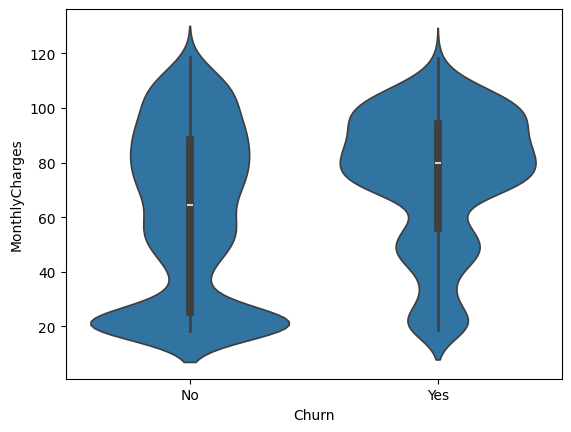

In [69]:
sns.violinplot(x='Churn', y='MonthlyCharges', data=df)
plt.savefig("images/monthlycharges_vs_churn.svg", bbox_inches="tight")

In [70]:
# Analyze MonthlyCharges with churn rate
print(f"high bill, more churn")
print(f"Low charges, less churn")

md_f.write(f"### 2. MonthlyCharges vs Churn:\n")
md_f.write(f"- high bill, more churn\n")
md_f.write(f"- Low charges, less churn\n\n")
md_f.write(f"![MonthlyCharges vs Churn](images/monthlycharges_vs_churn.svg)\n\n")


high bill, more churn
Low charges, less churn


64

### 3. Tenure vs Churn:
- Low tenure → high churn
- High tenure → loyal customers

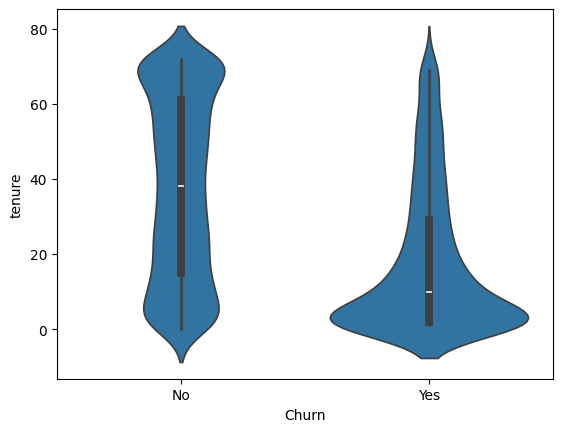

In [71]:
sns.violinplot(x='Churn', y='tenure', data=df)
plt.savefig("images/tenure_vs_churn.svg", bbox_inches="tight")

In [72]:
# Analyze Tenure with churn rate
print(f"Low tenure, high churn")
print(f"High tenure, loyal customers")

md_f.write(f"### 3. Tenure vs Churn:\n")
md_f.write(f"- Low tenure, high churn\n")
md_f.write(f"- High tenure, loyal customers\n\n")
md_f.write(f"![Tenure vs Churn](images/tenure_vs_churn.svg)\n\n")


Low tenure, high churn
High tenure, loyal customers


48

## Multivariate Analysis:

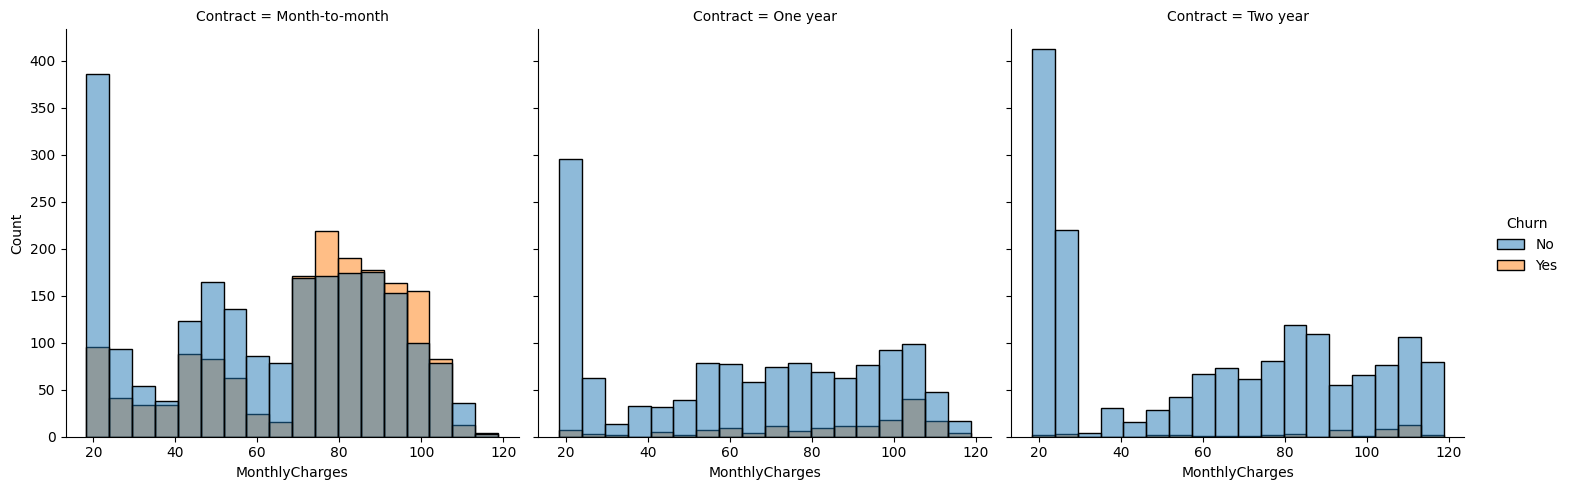

In [73]:
# scatter plot of Contract + MonthlyCharges + Churn
sns.displot(
    kind="hist",
    data=df,
    x="MonthlyCharges",
    col="Contract",
    hue="Churn"
).savefig(
    fig_path:=f"images/hist_contract_monthlycharges_churn.svg",
    bbox_inches='tight'
)

In [74]:
# Analyze contract with churn rate
print("""
Month-to-month Contract:
- High MonthlyCharges, more churn\n
- Low MonthlyCharges, comparatively less churn

One year Contract:
- Moderate churn

Two year Contract:
- Almost no churn (even if charges high)""")


md_f.write(f"---\n---\n## **Multivariate Analysis:**\n")
md_f.write(f"### Contract, MonthlyCharges, Churn:\n\n")
md_f.write(f"""
**Month-to-month Contract**\n
- High MonthlyCharges, more churn\n
- Low MonthlyCharges, comparatively less churn\n\n

**One year Contract**\n
- Moderate churn\n\n

**Two year Contract**\n
- Almost no churn (even if charges high)\n\n""")
md_f.write(f"![contract vs monthlycharges vs churn Histplot](images/hist_contract_monthlycharges_churn.svg)\n\n")



Month-to-month Contract:
- High MonthlyCharges, more churn

- Low MonthlyCharges, comparatively less churn

One year Contract:
- Moderate churn

Two year Contract:
- Almost no churn (even if charges high)


96

## Corelation Analysis:

In [75]:
df_encoded= df.copy()
df_encoded['gender'] = df_encoded['gender'].map({'Male':1, 'Female':0})
df_encoded['Partner'] = df_encoded['Partner'].map({'Yes':1, 'No':0})
df_encoded['Dependents'] = df_encoded['Dependents'].map({'Yes':1, 'No':0})
df_encoded['PhoneService'] = df_encoded['PhoneService'].map({'Yes':1, 'No':0})
df_encoded['PaperlessBilling'] = df_encoded['PaperlessBilling'].map({'Yes':1, 'No':0})
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes':1, 'No':0})

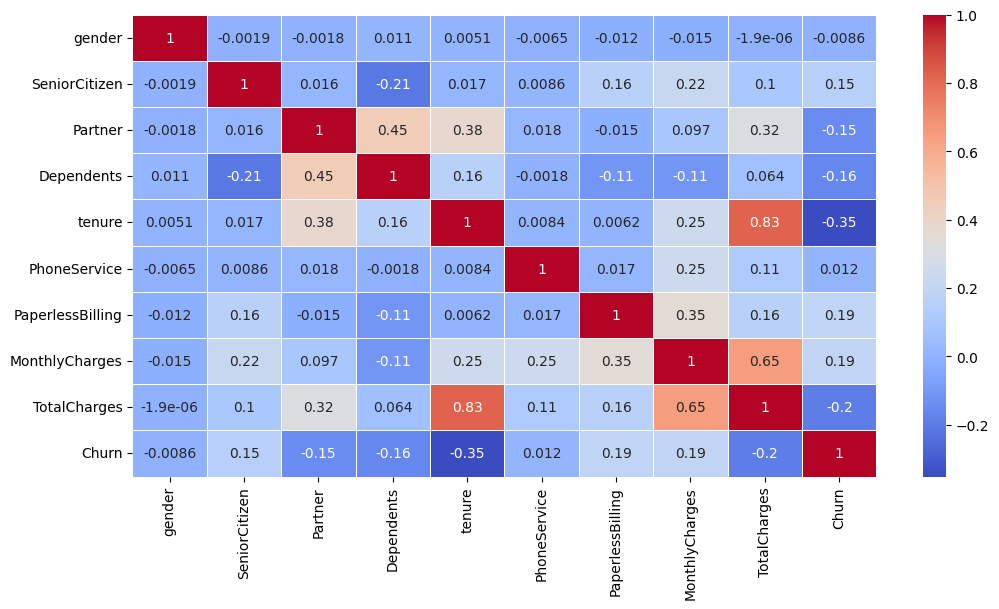

In [76]:
# heatmap plot for correlation

corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm',linewidths=0.5)
plt.savefig("images/correlations.svg", bbox_inches="tight")
plt.show()

In [77]:
# Correlated columns equal or above 0.7

threshold = 0.7
pairs = corr.where(((corr >= threshold) | (corr <= -threshold))).stack().reset_index()
pairs.columns = ['Feature1', 'Feature2', 'Correlation']
correlated_pairs = pairs[pairs["Feature1"] != pairs["Feature2"]].dropna()
correlated_pairs.reset_index(inplace=True, drop=True)

md_f.write(f"---\n---\n## **Correlation Analysis:**\n")
md_f.write(f"Highly correlated features, above {threshold}\n\n")
md_f.write(f"{correlated_pairs.to_markdown()}\n\n")
md_f.write(f"![Correlation](images/correlations.svg)\n\n")

correlated_pairs

,Feature1,Feature2,Correlation
0,tenure,TotalCharges,0.825464
1,TotalCharges,tenure,0.825464


In [78]:
# Key busines insights

md_f.write('''
---\n---\n## **Key Business Insights:**\n
- Month-to-month contracts have highest churn\n
- Low tenure customers are most likely to churn\n
- High monthly charges increase churn risk\n\n
''')
print('''Key Business Insights:
- Month-to-month contracts have highest churn
- Low tenure customers are most likely to churnn
- High monthly charges increase churn risk
''')


Key Business Insights:
- Month-to-month contracts have highest churn
- Low tenure customers are most likely to churnn
- High monthly charges increase churn risk



In [79]:
md_f.close()